Total rows/columns: (95472, 11)


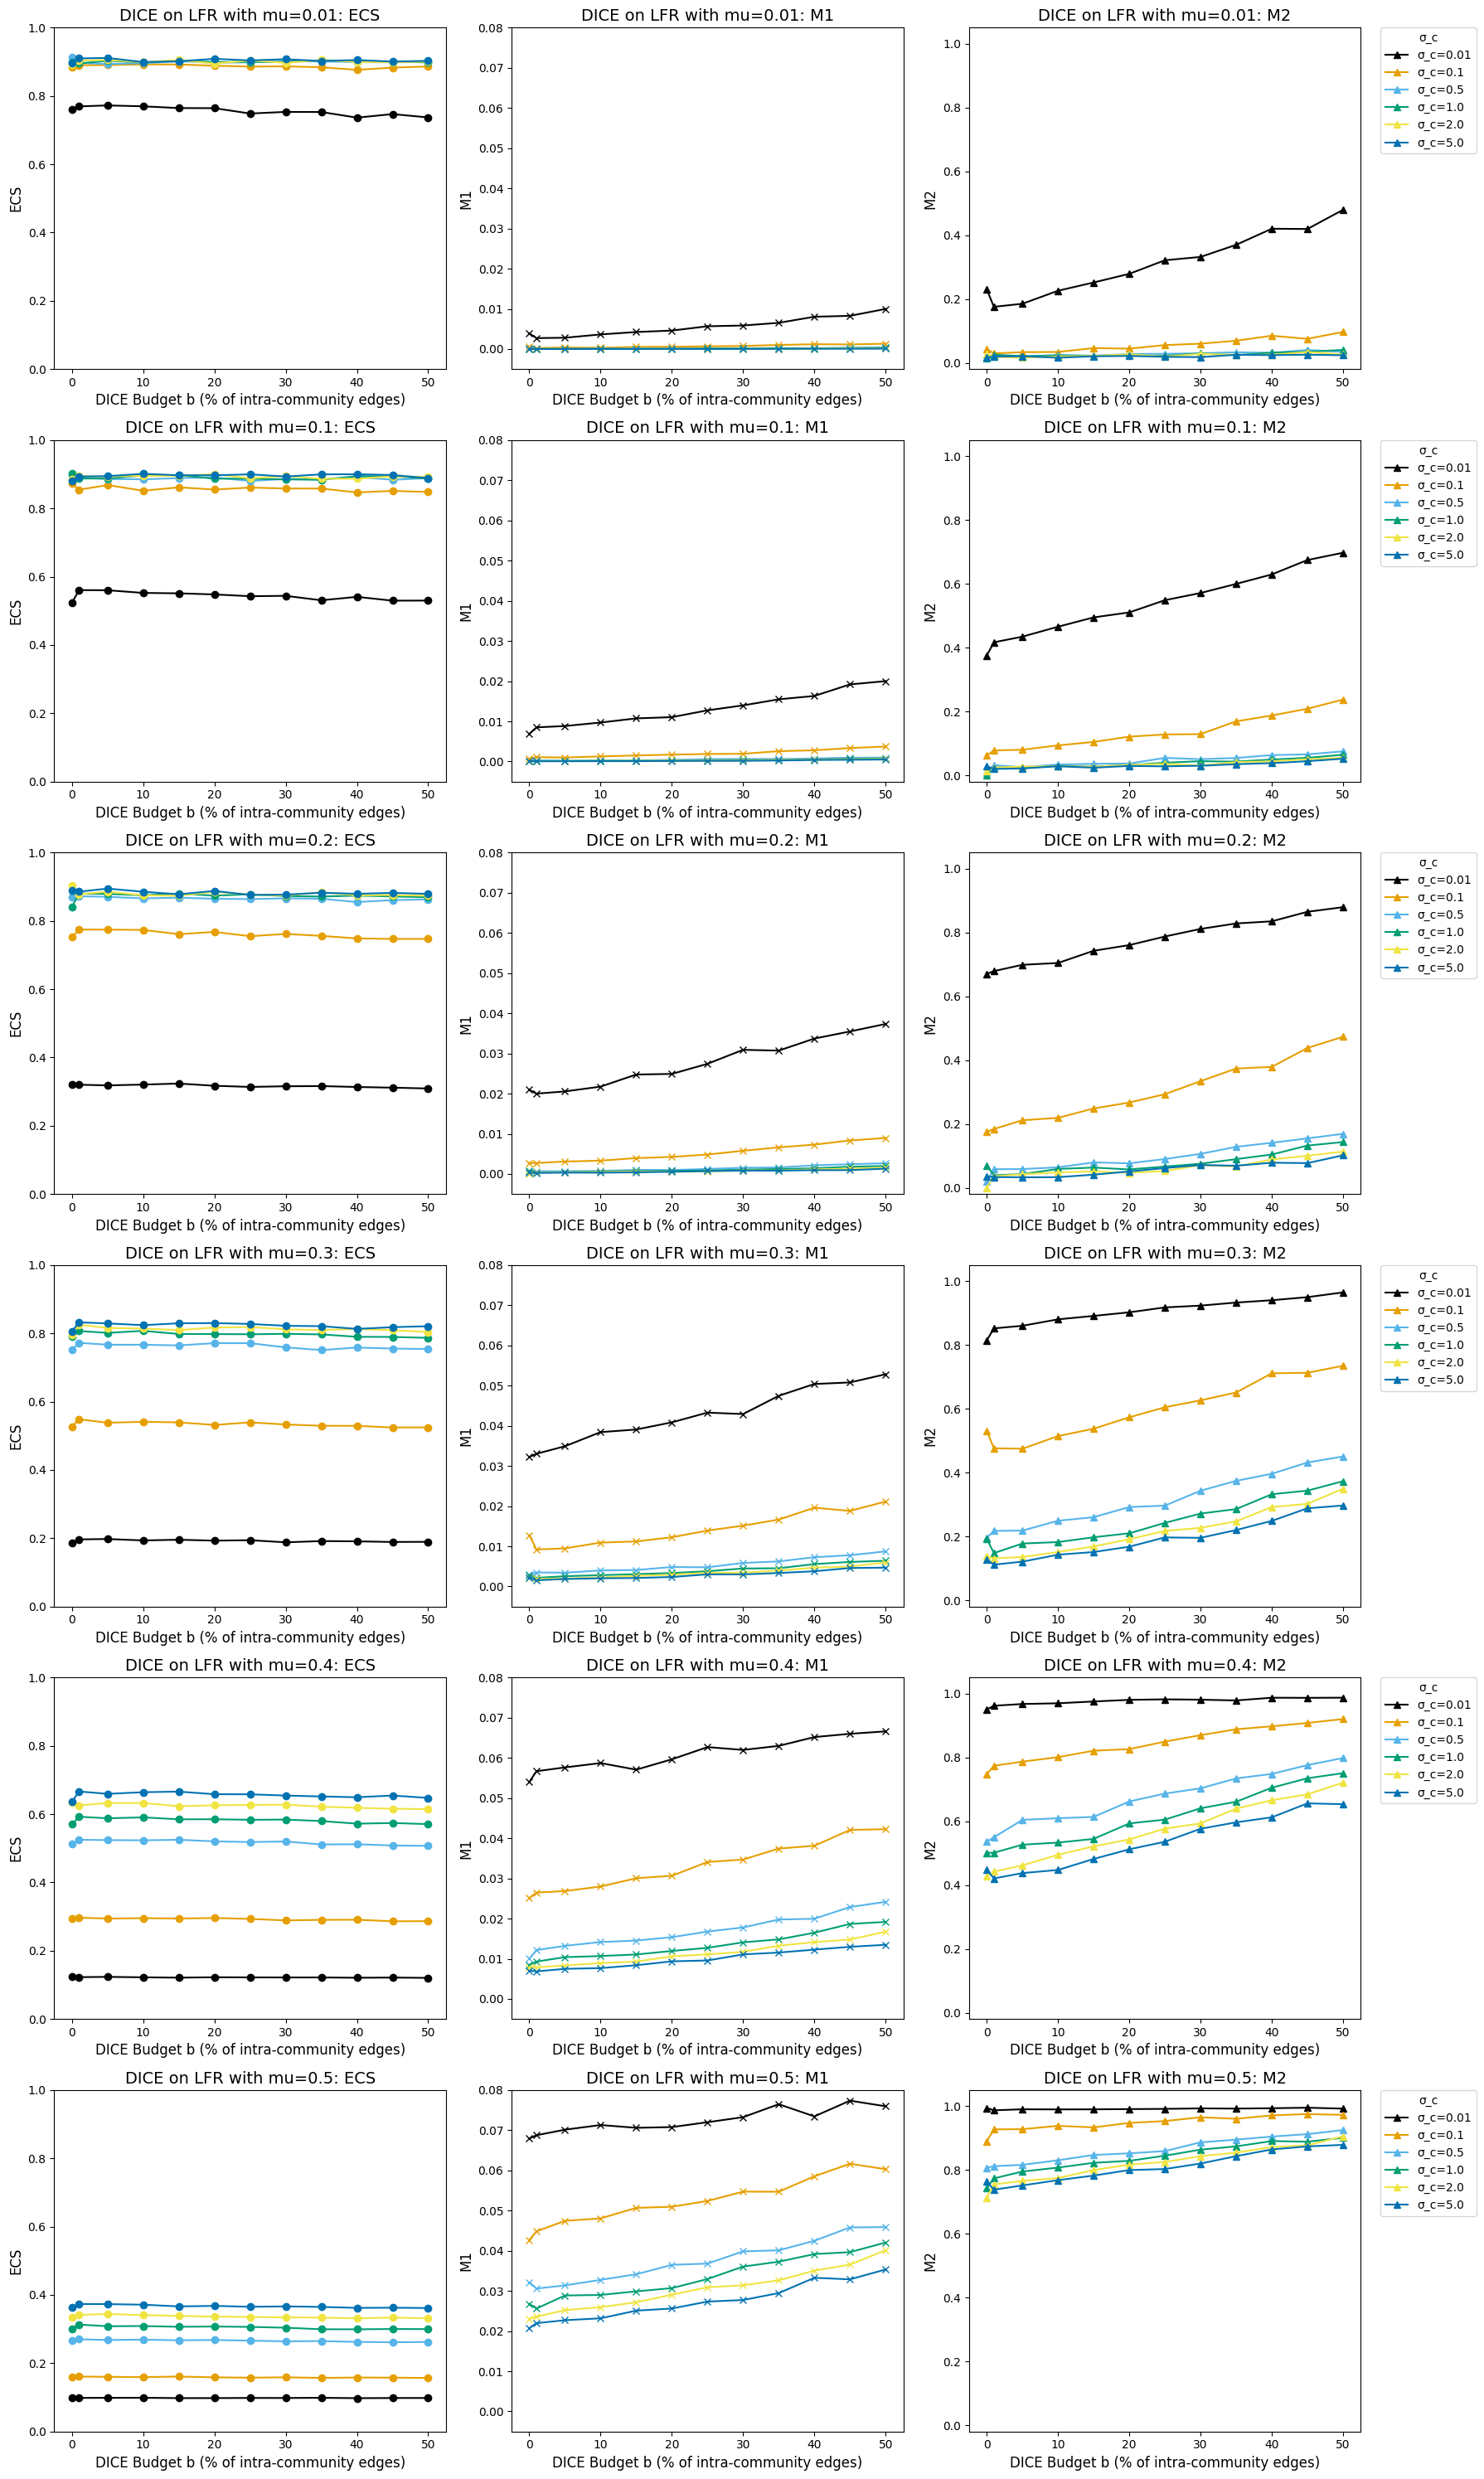

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob


# plt.style.use('tableau-colorblind10')
csv_files = glob.glob("full_bigred200_*.csv")  

# Combine all CSVs into one DataFrame
df_list = [pd.read_csv(file) for file in csv_files]
df = pd.concat(df_list, ignore_index=True)

print(f'Total rows/columns: {df.shape}') 

mu_values = sorted(df['mu'].unique())
sigma_c_values = sorted(df['sigma_c'].unique())

# # Colorblind-friendly colormap
# cmap = plt.cm.Set2
# # cmap = plt.cm.tab20
# colors = [cmap(i) for i in range(len(sigma_c_values))]
# color_map = {s: colors[i] for i, s in enumerate(sigma_c_values)}
# Jfly CUD color palette (hex)
cud_colors = [
    "#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442", 
    "#0072B2", "#D55E00", "#CC79A7"
]
color_map = {s: cud_colors[i % len(cud_colors)] for i, s in enumerate(sigma_c_values)}


metric_markers = {
    'ECS': 'o',
    'M1': 'x',
    'M2': '^',  # triangle up
}

metrics = ['ECS', 'M1', 'M2']
titles = {
    'ECS': lambda mu: f"DICE on LFR with mu={mu}: ECS",
    'M1': lambda mu: f"DICE on LFR with mu={mu}: M1",
    'M2': lambda mu: f"DICE on LFR with mu={mu}: M2"
}

fig, axes = plt.subplots(len(mu_values), 3, figsize=(20, 5 * len(mu_values)), sharex=True)

for row_idx, mu in enumerate(mu_values):
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx][col_idx] if len(mu_values) > 1 else axes[0][col_idx]
        for sigma_idx, sigma_c in enumerate(sigma_c_values):
            subdf = df[(df['mu'] == mu) & (df['sigma_c'] == sigma_c)]
            grouped = subdf.groupby('b_percentage').agg({metric: 'mean'}).reset_index()
            xvals = grouped['b_percentage'] * 100
            color = color_map[sigma_c]
            marker = metric_markers[metric]
            ax.plot(xvals, grouped[metric], marker=marker, linestyle='-', color=color, label=f'σ_c={sigma_c}')
        ax.set_title(titles[metric](mu), fontsize=14)
        ax.set_xlabel("DICE Budget b (% of intra-community edges)", fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        axes[row_idx, 0].set_ylim(0, 1.0)   # ECS
        axes[row_idx, 1].set_ylim(-0.005, 0.08)   # M1
        axes[row_idx, 2].set_ylim(-0.02, 1.05)   # M2
        ax.grid(False)
        # Only add legend to the last column
        if col_idx == 2:
            ax.legend(title='σ_c', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# --- FORCE X-TICKS ON ALL SUBPLOTS ---
for row_idx in range(len(mu_values)):
    for col_idx in range(3):
        ax = axes[row_idx][col_idx] if len(mu_values) > 1 else axes[0][col_idx]
        ax.tick_params(axis='x', which='both', labelbottom=True)
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()
